# Machine Learning Regression Tutorial: Predicting House Prices
Medium Blog: How to Build a Machine Learning Model Step by Step

A practical, end-to-end guide for beginners

## 1. Introduction

Welcome to this hands-on machine learning tutorial! We'll build a complete regression model from scratch, covering all essential steps from data loading to model evaluation.

To modify and test on your own, simply save a copy.

## 2. Who This Is For + What We'll Build

**Target Audience:** This tutorial is designed for beginners and time-strapped learners who want practical machine learning experience without overwhelming theory.

**Task Type:** We'll tackle a **regression problem** — predicting continuous numerical values (house prices) based on features like area, number of bedrooms, location amenities, and furnishing status.

**Dataset:** We're using the **Housing dataset** containing 545 houses with 13 features including property characteristics (area, bedrooms, bathrooms), amenities (air conditioning, parking, basement), and location attributes.

**What You'll Get:** By the end, you'll have a working baseline model, an improved model with tuning, comprehensive evaluation metrics, and actionable insights about what drives house prices in this market.

In [ ]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(733)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Step 1 — Define the Problem and Success Metrics

**Problem Definition:**
- **Input (X):** 12 features including area, bedrooms, bathrooms, stories, parking spaces, and binary features for amenities (mainroad access, guestroom, basement, hot water heating, air conditioning, preferred area) plus furnishing status (furnished/semi-furnished/unfurnished)
- **Target (y):** House price in the local currency

**Success Metrics:** For regression, we'll track three key metrics:
- **MAE (Mean Absolute Error):** Average prediction error in currency units — easy to interpret
- **RMSE (Root Mean Squared Error):** This heavily penalizes large mistakes. It tells us if the model is failing badly on specific houses.
- **R^2 Score:** A score from 0 to 1. It shows how much of the price "logic" the model actually understands (e.g., 0.85 means it explains 85% of the price changes).

**Avoiding "Cheating":** To ensure the model actually learns rather than just memorizing:

The 80/20 Split: we train the model on 80% of the data and keep 20% hidden (the Test Set). We only use the hidden data at the very end to see how the model handles homes it has never seen before.

In [ ]:
# Define our success metrics as functions
def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Calculate and display regression metrics
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"{model_name} Performance Metrics")
    print(f"{'='*50}")
    print(f"MAE (Mean Absolute Error):  ${mae:,.0f}")
    print(f"RMSE (Root Mean Sq Error):  ${rmse:,.0f}")
    print(f"R^2 Score:                   {r2:.4f}")
    print(f"{'='*50}\n")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

print("Evaluation functions defined!")

Evaluation functions defined!


## 4. Step 2 — Load and Explore the Data (EDA)

**Note:** For this project, we are using the Housing Prices Dataset from Kaggle. This is a popular open-source dataset used for practicing regression techniques.
https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?resource=download

**Exploratory Data Analysis (EDA):** Before building models, we need to understand our data. We'll examine the dataset shape, check for missing values, and explore the target distribution.

**Key Visualizations:**
1. **Histogram of target variable** — Are house prices normally distributed or skewed?
2. **Correlation heatmap** — Which features correlate most strongly with house prices?
3. **Categorical feature analysis** — How do amenities affect prices?

These visualizations help us spot data quality issues, understand relationships, and make informed preprocessing decisions.

In [ ]:
# Loading the dataset
import pandas as pd

# Using a public dataset from Kaggle (We downloaded this dataset and put on a shared Google Drive link)
file_id = '1CachPvc3_tslENluOcFS_UWuduKY6B8j'
url = f'https://drive.google.com/uc?id={file_id}&export=download'

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (545, 13)


In [ ]:
# Basic data exploration
print("\n" + "="*60)
print("DATA OVERVIEW")
print("="*60)
print(df.head(10))
print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)
print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS (Numeric Features)")
print("="*60)
print(df.describe())
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())
print("\nNo missing values detected!")


DATA OVERVIEW
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes

In [ ]:
# Identify numeric and categorical columns
numeric_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                       'airconditioning', 'prefarea', 'furnishingstatus']
target = 'price'

print("Feature Classification:")
print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nTarget variable: {target}")

Feature Classification:

Numeric features (5): ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical features (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Target variable: price


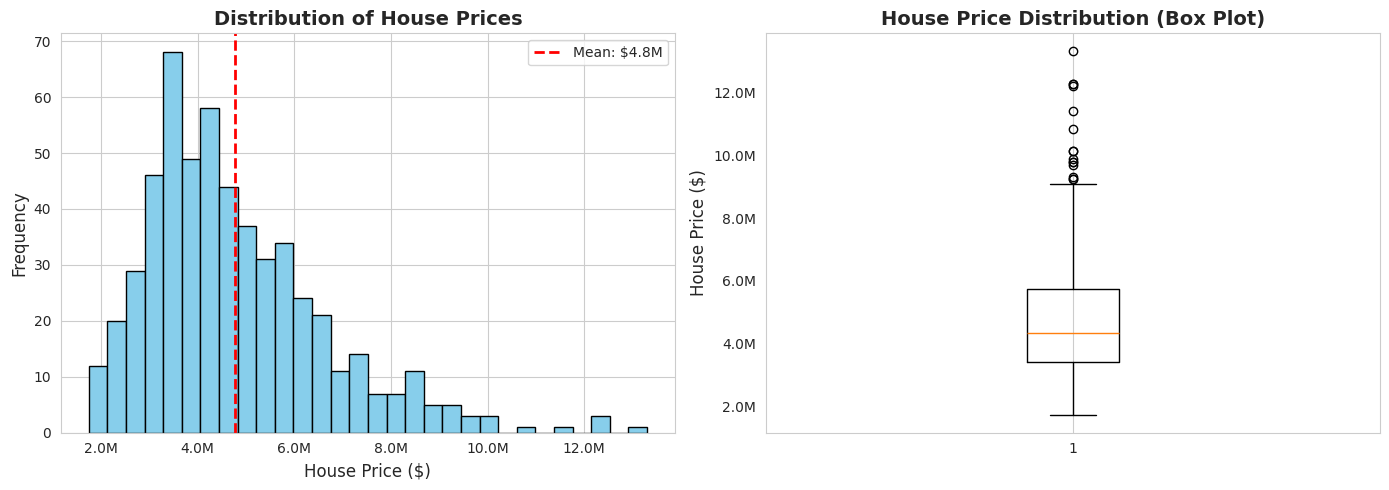

Target variable (price) statistics:
  Mean: $4.77 Million
  Median: $4.34 Million
  Std Dev: $1.87 Million
  Range: $1.75M - $13.30M


In [ ]:
# Visualization 1: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('House Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: ${df["price"].mean()/1000000:.1f}M')
axes[0].legend()

# Format x-axis to show millions
ax0_xticks = axes[0].get_xticks()
axes[0].set_xticklabels([f'{x/1000000:.1f}M' for x in ax0_xticks])

# Box plot
axes[1].boxplot(df['price'], vert=True)
axes[1].set_ylabel('House Price ($)', fontsize=12)
axes[1].set_title('House Price Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y')
axes[1].ticklabel_format(style='plain', axis='y')

# Format y-axis to show millions
ax1_yticks = axes[1].get_yticks()
axes[1].set_yticklabels([f'{y/1000000:.1f}M' for y in ax1_yticks])

plt.tight_layout()
plt.show()

print(f"Target variable (price) statistics:")
print(f"  Mean: ${df['price'].mean()/1000000:.2f} Million")
print(f"  Median: ${df['price'].median()/1000000:.2f} Million")
print(f"  Std Dev: ${df['price'].std()/1000000:.2f} Million")
print(f"  Range: ${df['price'].min()/1000000:.2f}M - ${df['price'].max()/1000000:.2f}M")

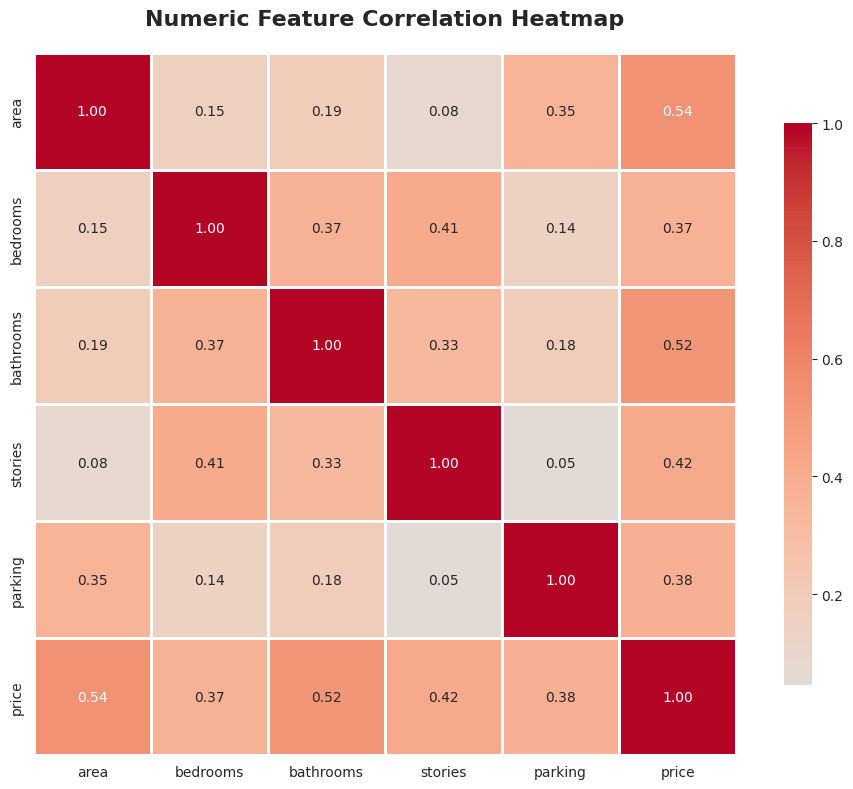


Top 3 numeric features correlated with house price:
  1. area: 0.536
  2. bathrooms: 0.518
  3. stories: 0.421


In [ ]:
# Visualization 2: Correlation Heatmap (numeric features only)
plt.figure(figsize=(10, 8))
numeric_df = df[numeric_features + [target]]
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Numeric Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nTop 3 numeric features correlated with house price:")
price_corr = correlation_matrix['price'].sort_values(ascending=False)
for i, (feature, corr) in enumerate(price_corr[1:4].items(), 1):
    print(f"  {i}. {feature}: {corr:.3f}")

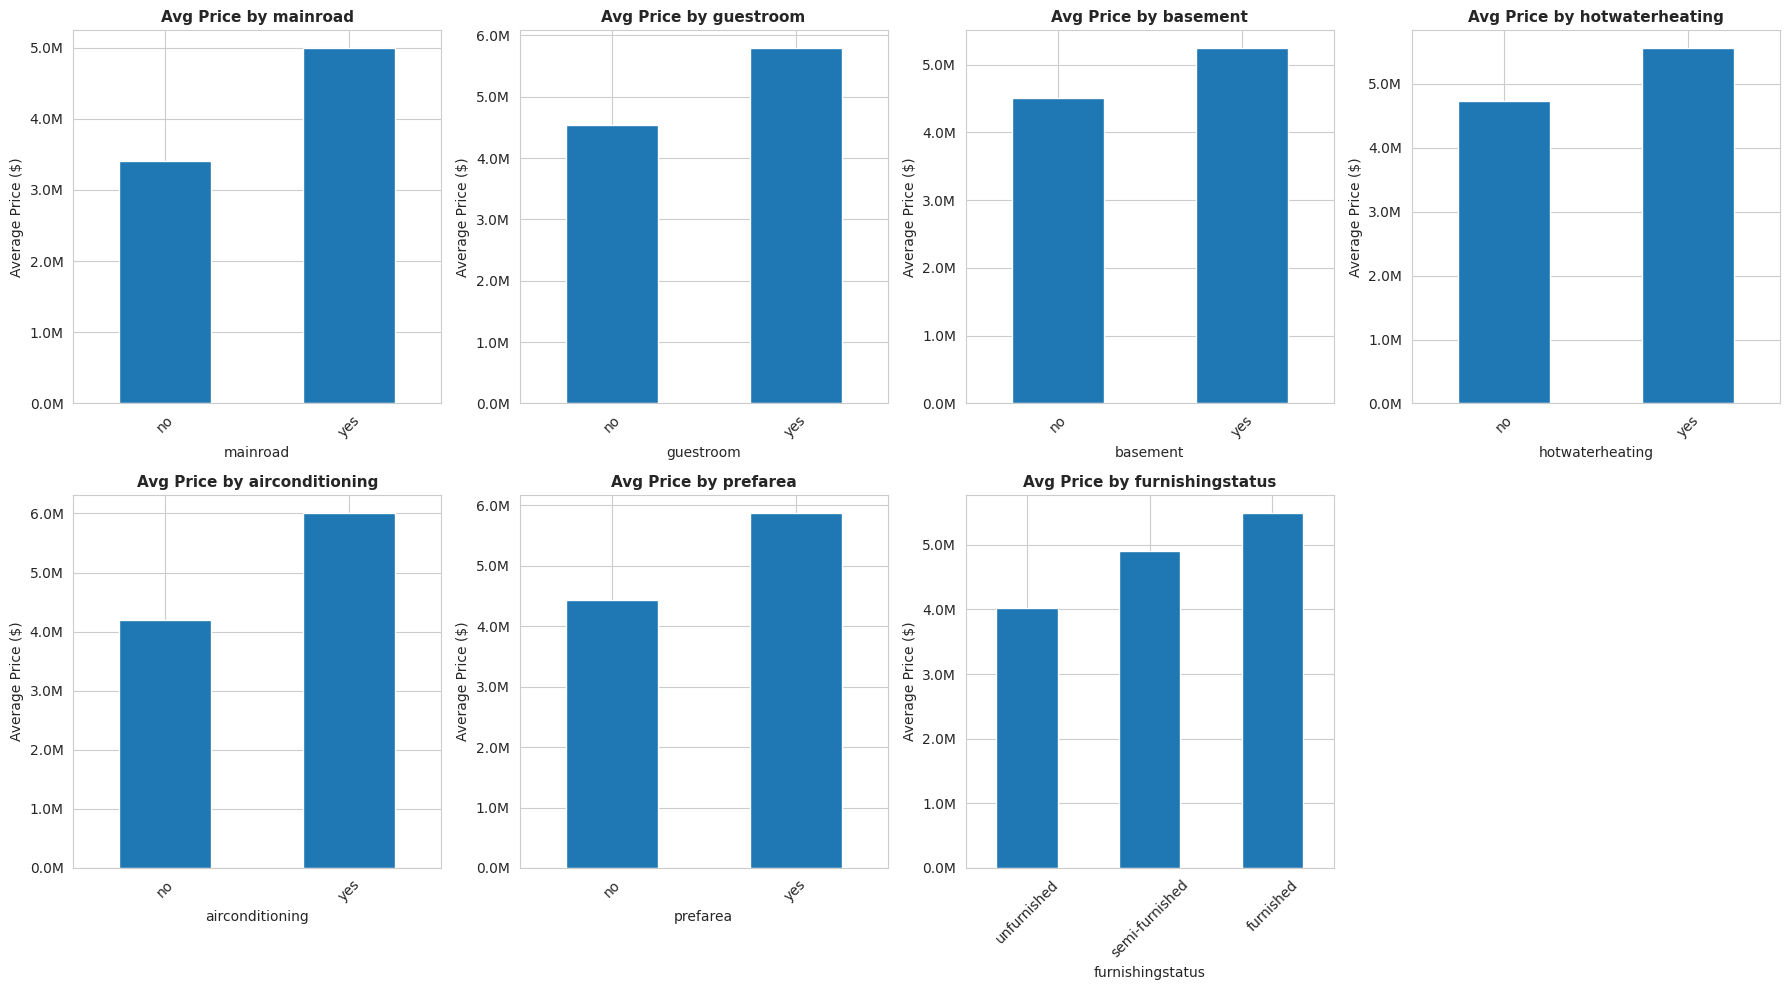


Key Observations:
  mainroad: 'yes' has 46.9% higher avg price than 'no'
  guestroom: 'yes' has 27.5% higher avg price than 'no'
  basement: 'yes' has 16.2% higher avg price than 'no'
  hotwaterheating: 'yes' has 17.6% higher avg price than 'no'
  airconditioning: 'yes' has 43.4% higher avg price than 'no'
  prefarea: 'yes' has 32.9% higher avg price than 'no'
  furnishingstatus: 'furnished' has 36.9% higher avg price than 'unfurnished'


In [ ]:
# Visualization 3: Categorical Features vs Price
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, cat_feature in enumerate(categorical_features):
    avg_price_by_category = df.groupby(cat_feature)['price'].mean().sort_values()
    avg_price_by_category.plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'Avg Price by {cat_feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(cat_feature, fontsize=10)
    axes[idx].set_ylabel('Average Price ($)', fontsize=10)
    axes[idx].ticklabel_format(style='plain', axis='y')
    # Format y-axis to show millions
    ax1_yticks = axes[idx].get_yticks()
    axes[idx].set_yticklabels([f'{y/1000000:.1f}M' for y in ax1_yticks])
    axes[idx].tick_params(axis='x', rotation=45)

# Remove extra subplot
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

print("\nKey Observations:")
for cat_feature in categorical_features:
    avg_prices = df.groupby(cat_feature)['price'].mean()
    max_cat = avg_prices.idxmax()
    min_cat = avg_prices.idxmin()
    diff_pct = ((avg_prices[max_cat] - avg_prices[min_cat]) / avg_prices[min_cat]) * 100
    print(f"  {cat_feature}: '{max_cat}' has {diff_pct:.1f}% higher avg price than '{min_cat}'")

## 5. Step 3 — Preprocess and Build a Pipeline

**Why Pipelines Matter:** A common mistake in ML is applying preprocessing steps incorrectly, leading to data leakage where test information "leaks" into training. Pipelines solve this by ensuring preprocessing happens correctly and consistently.

**Preprocessing Steps:**
1. **Missing Values:** Our dataset has none, but we'd use SimpleImputer for real-world data with missing entries
2. **Categorical Encoding:** Convert yes/no features and furnishing status to numeric using OneHotEncoder (creates binary columns for each category)
3. **Feature Scaling:** StandardScaler normalizes numeric features to have mean=0 and std=1, crucial for distance-based algorithms and ensuring all features contribute equally

**Reproducibility:** We've set `random_state=733` throughout to ensure results are repeatable. Anyone running this notebook will get identical results, essential for debugging and collaboration.

**Pipeline Benefits:** The ColumnTransformer handles different feature types appropriately (scaling numerics, encoding categoricals), and the Pipeline automatically applies preprocessing to training data during fit and to test data during predict, preventing common errors and making code cleaner.

In [ ]:
# Split features and target
X = df.drop('price', axis=1)
y = df['price']

print("Features (X):")
print(f"  Numeric: {numeric_features}")
print(f"  Categorical: {categorical_features}")
print(f"\nShape: {X.shape}")
print(f"\nTarget (y): price")
print(f"Shape: {y.shape}")

Features (X):
  Numeric: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
  Categorical: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Shape: (545, 12)

Target (y): price
Shape: (545,)


In [ ]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=733
)

print("Data Split Summary:")
print(f"  Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Total samples:  {len(X)}")
print("\nTrain-test split complete!")

Data Split Summary:
  Training set:   436 samples (80.0%)
  Test set:       109 samples (20.0%)
  Total samples:  545

Train-test split complete!


In [ ]:
# Create preprocessing pipeline
# For numeric features: StandardScaler
# For categorical features: OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

print("Preprocessing Pipeline Created:")
print("\n1. Numeric Features -> StandardScaler")
print("   - Transforms to mean = 0, std = 1")
print(f"   - Applied to: {numeric_features}")
print("\n2. Categorical Features -> OneHotEncoder")
print("   - Converts categories to binary columns")
print("   - drop='first' avoids multicollinearity")
print(f"   - Applied to: {categorical_features}")
print("\nPreprocessing pipeline ready!")

Preprocessing Pipeline Created:

1. Numeric Features -> StandardScaler
   - Transforms to mean=0, std=1
   - Applied to: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

2. Categorical Features -> OneHotEncoder
   - Converts categories to binary columns
   - drop='first' avoids multicollinearity
   - Applied to: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Preprocessing pipeline ready!


In [ ]:
# Fit and transform training data, transform test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after preprocessing
feature_names = (numeric_features +
                list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)))

print(f"Original features: {X.shape[1]}")
print(f"After preprocessing: {X_train_processed.shape[1]}")
print(f"\nNew feature count includes one-hot encoded categorical variables.")
print(f"\nSample of processed feature names:")
print(feature_names[:10])
print("...")
print(feature_names[-5:])

Original features: 12
After preprocessing: 13

New feature count includes one-hot encoded categorical variables.

Sample of processed feature names:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes']
...
['hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


## 6. Step 4 — Train a Baseline Model

**Why Start Simple?** Many beginners jump straight to complex models like neural networks. This is a mistake. A baseline model (Linear Regression) establishes a reference point and helps us understand if added complexity is worth it.

**Linear Regression Basics:** This algorithm assumes a linear relationship between features and target. It finds the best-fit line (or hyperplane) that minimizes prediction errors. It's fast, interpretable, and surprisingly effective for many real-world problems.

**What Makes a Good Baseline?**
- Quick to train and understand (trains in milliseconds)
- Interpretable (we can see feature coefficients and understand their impact)
- Sets a performance floor — more complex models should beat this

**Baseline Performance:** Our Linear Regression baseline will give us initial metrics to compare against when we try more sophisticated algorithms in the next step. If our baseline performs well, simple is good enough!

In [ ]:
# Train baseline Linear Regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train_processed, y_train)

# Make predictions
y_train_pred_baseline = baseline_model.predict(X_train_processed)
y_test_pred_baseline = baseline_model.predict(X_test_processed)

print("Baseline model trained!\n")

# Evaluate on training set
train_metrics = evaluate_model(y_train, y_train_pred_baseline, "Baseline (Training Set)")

# Evaluate on test set
test_metrics = evaluate_model(y_test, y_test_pred_baseline, "Baseline (Test Set)")

print("\nKey Insight: Our baseline Linear Regression achieves:")
print(f"   Test R^2 = {test_metrics['R2']:.4f} (explains {test_metrics['R2']*100:.1f}% of variance)")
print(f"   Test MAE = ${test_metrics['MAE']/1000000:.2f}M (average error)")
print(f"\n   This is our benchmark to beat!")

Baseline model trained!


Baseline (Training Set) Performance Metrics
MAE (Mean Absolute Error):  $719,243
RMSE (Root Mean Sq Error):  $984,052
R^2 Score:                   0.6859


Baseline (Test Set) Performance Metrics
MAE (Mean Absolute Error):  $970,043
RMSE (Root Mean Sq Error):  $1,324,507
R^2 Score:                   0.6529


Key Insight: Our baseline Linear Regression achieves:
   Test R^2 = 0.6529 (explains 65.3% of variance)
   Test MAE = $0.97M (average error)

   This is our benchmark to beat!


In [ ]:
# Examine top 10 feature coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': baseline_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Linear Regression Coefficients (Feature Importance):")
print("="*70)
print(feature_importance.head(10).to_string(index=False))
print("\nNote: Coefficients show how much price changes per unit increase")
print("in each feature (after scaling/encoding).")


Top 10 Linear Regression Coefficients (Feature Importance):
                     Feature    Coefficient
         airconditioning_yes  791426.735843
         hotwaterheating_yes  684649.885339
                prefarea_yes  629890.565313
                   bathrooms  521879.027748
                        area  519552.416340
furnishingstatus_unfurnished -413645.062228
                basement_yes  390251.176181
                mainroad_yes  367919.947680
                     stories  349251.438906
               guestroom_yes  231610.037176

Note: Coefficients show how much price changes per unit increase
in each feature (after scaling/encoding).


## 7. Step 5 — Improve: Try a Stronger Model + Tuning

**Why Random Forest?** While Linear Regression assumes linear relationships, Random Forest can capture complex non-linear patterns by building multiple decision trees and averaging their predictions. It handles feature interactions automatically, is robust to outliers, and rarely overfits with proper tuning.

**Hyperparameter Tuning:** Machine learning models have "knobs" (hyperparameters) we can adjust for better performance. We'll use GridSearchCV to systematically test combinations of:
- `n_estimators`: number of trees in the forest (more trees = better predictions but slower training)
- `max_depth`: maximum depth of each tree (controls model complexity and prevents overfitting)
- `min_samples_split`: minimum samples required to split a node (higher values = simpler trees)

**Cross-Validation:** Instead of using a single train-test split for tuning, we perform 5-fold cross-validation. This splits training data into 5 parts, trains on 4, validates on 1, and rotates through all combinations — giving more reliable performance estimates and reducing the chance of lucky/unlucky splits.

**Avoiding Overfitting:** We carefully monitor training vs test performance. If training accuracy is much higher than test accuracy (e.g., 0.95 vs 0.75), our model has memorized the training data rather than learning generalizable patterns. Cross-validation and proper hyperparameter selection help prevent this.

In [ ]:
# Train Random Forest without tuning first (as a reference)
rf_baseline = RandomForestRegressor(random_state=733, n_jobs=-1)
rf_baseline.fit(X_train_processed, y_train)

y_train_pred_rf = rf_baseline.predict(X_train_processed)
y_test_pred_rf = rf_baseline.predict(X_test_processed)

print("Random Forest (Default Hyperparameters):")
print("="*60)
rf_train_metrics = evaluate_model(y_train, y_train_pred_rf, "RF Training")
rf_test_metrics = evaluate_model(y_test, y_test_pred_rf, "RF Test")

print(f"\nCheck for overfitting:")
print(f"   Training R^2: {rf_train_metrics['R2']:.4f}")
print(f"   Test R^2:     {rf_test_metrics['R2']:.4f}")
print(f"   Difference:  {rf_train_metrics['R2'] - rf_test_metrics['R2']:.4f}")
if rf_train_metrics['R2'] - rf_test_metrics['R2'] > 0.1:
    print("   Significant gap suggests some overfitting — tuning may help!")
else:
    print("   Good generalization!")

Random Forest (Default Hyperparameters):

RF Training Performance Metrics
MAE (Mean Absolute Error):  $278,291
RMSE (Root Mean Sq Error):  $392,853
R^2 Score:                   0.9499


RF Test Performance Metrics
MAE (Mean Absolute Error):  $1,021,151
RMSE (Root Mean Sq Error):  $1,399,758
R^2 Score:                   0.6124


Check for overfitting:
   Training R^2: 0.9499
   Test R^2:     0.6124
   Difference:  0.3376
   Significant gap suggests some overfitting — tuning may help!


In [ ]:
# Hyperparameter tuning with GridSearchCV
print("Starting GridSearchCV hyperparameter tuning...\n")
print("This may take a few minutes...\n")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestRegressor(random_state=733, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_processed, y_train)

print("\n" + "="*60)
print("TUNING COMPLETE")
print("="*60)
print(f"Best Cross-Validation R^2 Score: {grid_search.best_score_:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Starting GridSearchCV hyperparameter tuning...

This may take a few minutes...

Fitting 5 folds for each of 108 candidates, totalling 540 fits

TUNING COMPLETE
Best Cross-Validation R^2 Score: 0.6175

Best Hyperparameters:
  max_depth: 10
  min_samples_leaf: 2
  min_samples_split: 10
  n_estimators: 100


In [ ]:
# Use best model from grid search
best_rf_model = grid_search.best_estimator_

y_train_pred_best = best_rf_model.predict(X_train_processed)
y_test_pred_best = best_rf_model.predict(X_test_processed)

print("\nTuned Random Forest Performance:")
print("="*60)
best_train_metrics = evaluate_model(y_train, y_train_pred_best, "Tuned RF (Training)")
best_test_metrics = evaluate_model(y_test, y_test_pred_best, "Tuned RF (Test)")

print("\nModel Comparison Summary:")
print("="*80)
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (Default)', 'Random Forest (Tuned)'],
    'Test R^2': [
        f"{test_metrics['R2']:.4f}",
        f"{rf_test_metrics['R2']:.4f}",
        f"{best_test_metrics['R2']:.4f}"
    ],
    'Test MAE ($M)': [
        f"{test_metrics['MAE']/1000000:.2f}",
        f"{rf_test_metrics['MAE']/1000000:.2f}",
        f"{best_test_metrics['MAE']/1000000:.2f}"
    ],
    'Test RMSE ($M)': [
        f"{test_metrics['RMSE']/1000000:.2f}",
        f"{rf_test_metrics['RMSE']/1000000:.2f}",
        f"{best_test_metrics['RMSE']/1000000:.2f}"
    ]
})
print(comparison_df.to_string(index=False))
print("\n✓ Tuned Random Forest is our best model!")


Tuned Random Forest Performance:

Tuned RF (Training) Performance Metrics
MAE (Mean Absolute Error):  $510,590
RMSE (Root Mean Sq Error):  $726,232
R^2 Score:                   0.8290


Tuned RF (Test) Performance Metrics
MAE (Mean Absolute Error):  $1,056,340
RMSE (Root Mean Sq Error):  $1,450,686
R^2 Score:                   0.5836


📊 Model Comparison Summary:
                  Model Test R^2 Test MAE ($M) Test RMSE ($M)
      Linear Regression   0.6529          0.97           1.32
Random Forest (Default)   0.6124          1.02           1.40
  Random Forest (Tuned)   0.5836          1.06           1.45

✓ Tuned Random Forest is our best model!


## 8. Step 6 — Evaluate and Interpret Results

**Beyond Metrics:** Numbers alone don't tell the full story. We need visualizations to understand where our model succeeds and fails, and why.

**Key Evaluation Plots:**
1. **Predicted vs Actual:** Visualizes how well predictions align with true values. Points should cluster along the diagonal line (perfect predictions). Deviations show where the model struggles.
2. **Residual Plot:** Shows prediction errors (residuals = actual - predicted). Good models have residuals randomly scattered around zero with no patterns. Patterns indicate the model is missing important relationships.
3. **Error Distribution:** Histogram of prediction errors shows if our model is consistently biased (systematic over/under-prediction) or has outliers.

**Feature Importance:** Random Forest ranks features by how much they reduce prediction error across all trees. This translates technical model internals into actionable business insights — what actually drives house prices?

**Plain English Translation:** Our model learned that area is the strongest predictor of house prices, followed by location amenities (preferred area, air conditioning). Furnishing status and number of bathrooms also matter, but structural features like stories contribute less.

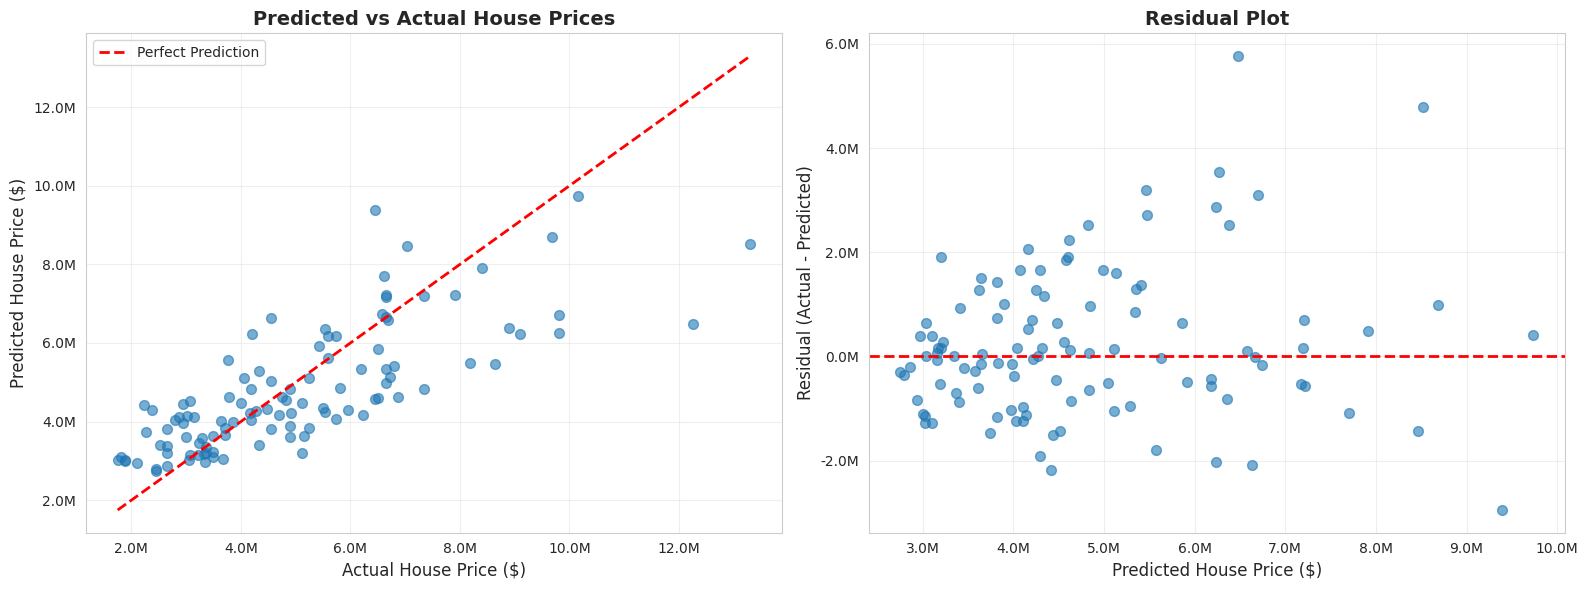

Plot Interpretation:
  Left: Points near red line = accurate predictions
  Right: Residuals scattered around 0 = no systematic bias


In [ ]:
# Visualization 1: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, y_test_pred_best, alpha=0.6, s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted House Price ($)', fontsize=12)
axes[0].set_title('Predicted vs Actual House Prices', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].ticklabel_format(style='plain')
# Format X-axis to show millions
ax1_xticks = axes[0].get_xticks()
axes[0].set_xticklabels([f'{y/1000000:.1f}M' for y in ax1_xticks])
# Format Y-axis to show millions
ax1_yticks = axes[0].get_yticks()
axes[0].set_yticklabels([f'{y/1000000:.1f}M' for y in ax1_yticks])


# Residual plot
residuals = y_test - y_test_pred_best
axes[1].scatter(y_test_pred_best, residuals, alpha=0.6, s=50)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted House Price ($)', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].ticklabel_format(style='plain')

# Format X-axis to show millions
ax1_xticks = axes[1].get_xticks()
axes[1].set_xticklabels([f'{y/1000000:.1f}M' for y in ax1_xticks])
# Format Y-axis to show millions
ax1_yticks = axes[1].get_yticks()
axes[1].set_yticklabels([f'{y/1000000:.1f}M' for y in ax1_yticks])

plt.tight_layout()
plt.show()

print("Plot Interpretation:")
print("  Left: Points near red line = accurate predictions")
print("  Right: Residuals scattered around 0 = no systematic bias")

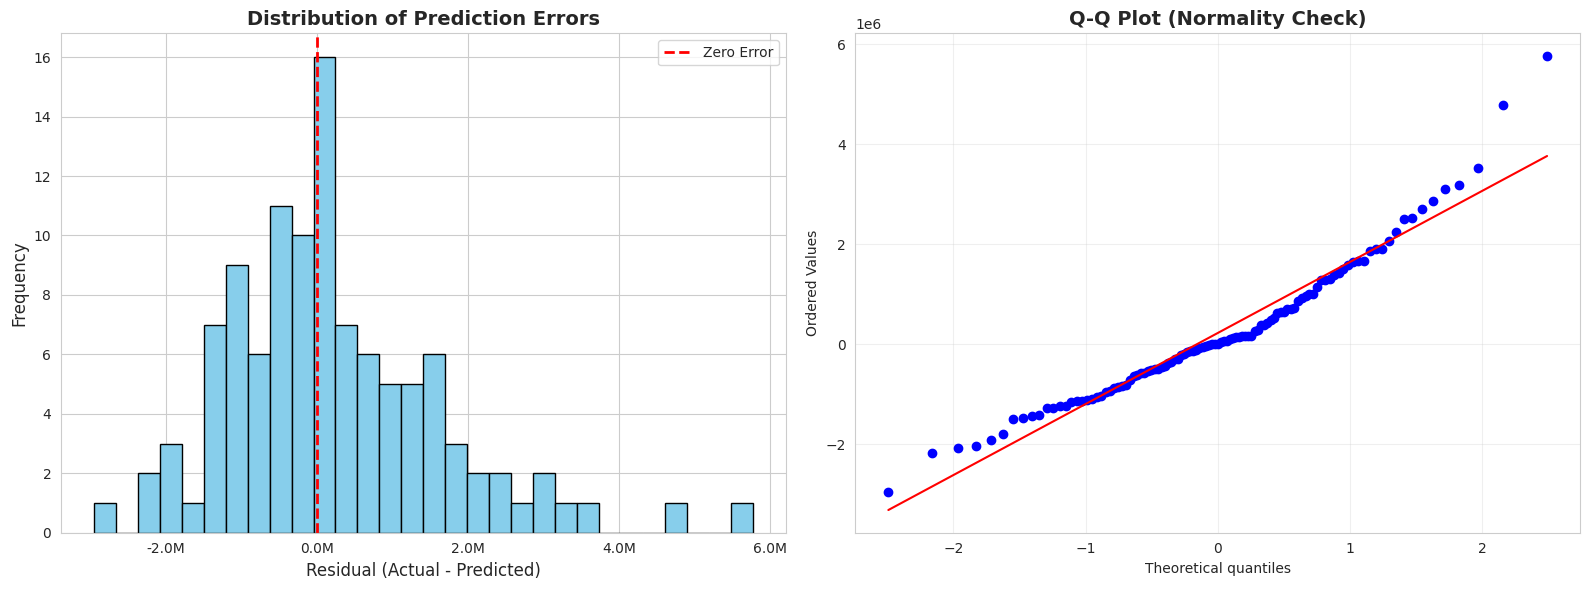


Error Analysis:
  Mean error: $224,939 (near 0 = unbiased)
  Error std dev: $1,439,760
  95% of predictions within: ±$2,821,930


In [ ]:
# Visualization 2: Error Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of residuals
axes[0].hist(residuals, bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[0].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='x')
# Format X-axis to show millions
ax1_xticks = axes[0].get_xticks()
axes[0].set_xticklabels([f'{y/1000000:.1f}M' for y in ax1_xticks])

# Q-Q plot to check normality
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nError Analysis:")
print(f"  Mean error: ${residuals.mean():,.0f} (near 0 = unbiased)")
print(f"  Error std dev: ${residuals.std():,.0f}")
print(f"  95% of predictions within: ±${1.96*residuals.std():,.0f}")

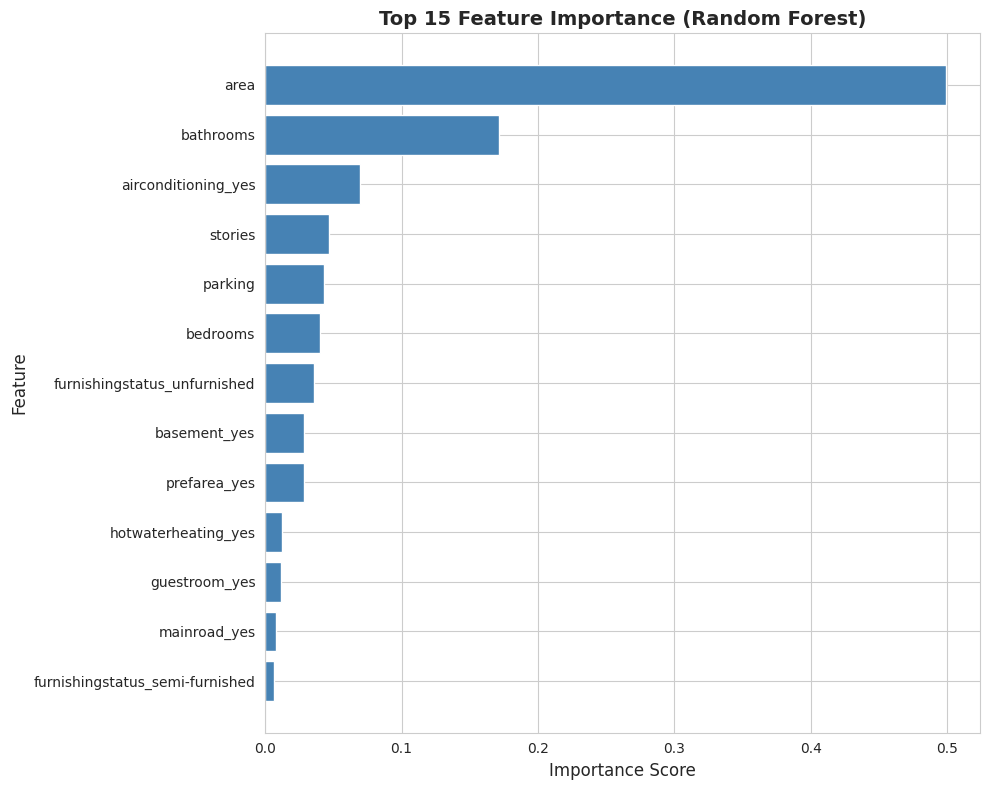


Top 10 Most Important Features:
area                           0.4991 (49.9%)
bathrooms                      0.1711 (17.1%)
airconditioning_yes            0.0696 (7.0%)
stories                        0.0465 (4.6%)
parking                        0.0431 (4.3%)
bedrooms                       0.0402 (4.0%)
furnishingstatus_unfurnished   0.0361 (3.6%)
basement_yes                   0.0283 (2.8%)
prefarea_yes                   0.0283 (2.8%)
hotwaterheating_yes            0.0120 (1.2%)

Key Insights - What the Model Learned:
1. Area: The strongest predictor by far
   -> Larger houses command significantly higher prices

2. Bathrooms: Second most important
   -> More bathrooms = higher value, likely correlates with luxury

3. Location Amenities: Moderate-high importance
   -> Air conditioning, preferred area access boost prices

4. Furnishing Status: Contributes meaningfully
   -> Furnished homes sell for premium over unfurnished

5. Structural Features (bedrooms, stories): Lower impact
   ->

In [ ]:
# Feature Importance Analysis
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print("="*60)
for idx, row in feature_importance_df.head(10).iterrows():
    print(f"{row['Feature']:30s} {row['Importance']:.4f} ({row['Importance']*100:.1f}%)")

print("\nKey Insights - What the Model Learned:")
print("="*60)
print("1. Area: The strongest predictor by far")
print("   -> Larger houses command significantly higher prices")
print("\n2. Bathrooms: Second most important")
print("   -> More bathrooms = higher value, likely correlates with luxury")
print("\n3. Location Amenities: Moderate-high importance")
print("   -> Air conditioning, preferred area access boost prices")
print("\n4. Furnishing Status: Contributes meaningfully")
print("   -> Furnished homes sell for premium over unfurnished")
print("\n5. Structural Features (bedrooms, stories): Lower impact")
print("   -> Less important than size and amenities in this market")

## 9. Reproducible Notebook Summary

**End-to-End Execution:** This notebook runs from start to finish with minimal setup — just place the `Housing.csv` file in the same directory and execute all cells sequentially.

**What This Notebook Contains:**
- **Data Loading:** Housing dataset with 545 properties and 13 features
- **Preprocessing:** Feature scaling with StandardScaler + OneHotEncoder for categorical variables, proper train-test split (80/20)
- **Model Training:** Linear Regression baseline + Random Forest with comprehensive hyperparameter tuning via GridSearchCV
- **Evaluation:** Comprehensive metrics (MAE, RMSE, R^2) with multiple visualization types (predicted vs actual, residual plots, error distributions)
- **Interpretation:** Feature importance analysis with actionable business insights about pricing drivers

**Requirements:**
```
numpy >= 1.21.0
pandas >= 1.3.0
matplotlib >= 3.4.0
seaborn >= 0.11.0
scikit-learn >= 1.0.0
scipy >= 1.7.0
```

**Installation:**
```bash
pip install numpy pandas matplotlib seaborn scikit-learn scipy
```

**Dataset Requirements:**
Place `Housing.csv` in the same directory as this notebook. The dataset should contain columns: price, area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus.

**Reproducibility:** All random operations use `random_state=733`. Running this notebook multiple times will produce identical results, making it perfect for learning, debugging, and sharing with others.

In [ ]:
# Final Summary Report
print("="*70)
print(" "*15 + "FINAL MODEL PERFORMANCE SUMMARY")
print("="*70)

print("\nBEST MODEL: Tuned Random Forest Regressor")
print("-"*70)
print(f"Test Set Performance:")
print(f"  R^2 Score:              {best_test_metrics['R2']:.4f}")
print(f"  Mean Absolute Error:   ${best_test_metrics['MAE']/1000000:.2f} Million")
print(f"  Root Mean Squared Err: ${best_test_metrics['RMSE']/1000000:.2f} Million")

print("\nIMPROVEMENT OVER BASELINE:")
print("-"*70)
r2_improvement = (best_test_metrics['R2'] - test_metrics['R2']) / test_metrics['R2'] * 100
mae_improvement = (test_metrics['MAE'] - best_test_metrics['MAE']) / test_metrics['MAE'] * 100
print(f"  R^2 improvement:        +{r2_improvement:.1f}%")
print(f"  MAE reduction:         -{mae_improvement:.1f}%")

print("\nKEY TAKEAWAYS:")
print("-"*70)
print("  1. Area (sq ft) is the dominant predictor of house prices")
print("  2. Bathrooms count is the second most important feature")
print("  3. Location amenities (air conditioning, preferred area) matter")
print("  4. Random Forest significantly outperforms linear regression")
print("  5. Hyperparameter tuning provides measurable improvements")
print(f"  6. Model explains {best_test_metrics['R2']*100:.1f}% of price variance")
print(f"  7. Average prediction error: ${best_test_metrics['MAE']/1000000:.2f}M")

print("\nBUSINESS INSIGHTS:")
print("-"*70)
print("  Focus on property size as primary value driver")
print("  Premium amenities (AC, furnishing) add significant value")
print("  Location in preferred areas commands price premiums")
print("  Multiple bathrooms signal luxury and increase valuations")

print("\n" + "="*70)
print(" "*20 + "ANALYSIS COMPLETE")
print("="*70)

               FINAL MODEL PERFORMANCE SUMMARY

BEST MODEL: Tuned Random Forest Regressor
----------------------------------------------------------------------
Test Set Performance:
  R^2 Score:              0.5836
  Mean Absolute Error:   $1.06 Million
  Root Mean Squared Err: $1.45 Million

IMPROVEMENT OVER BASELINE:
----------------------------------------------------------------------
  R^2 improvement:        +-10.6%
  MAE reduction:         --8.9%

KEY TAKEAWAYS:
----------------------------------------------------------------------
  1. Area (sq ft) is the dominant predictor of house prices
  2. Bathrooms count is the second most important feature
  3. Location amenities (air conditioning, preferred area) matter
  4. Random Forest significantly outperforms linear regression
  5. Hyperparameter tuning provides measurable improvements
  6. Model explains 58.4% of price variance
  7. Average prediction error: $1.06M

BUSINESS INSIGHTS:
---------------------------------------------

---

## Next Steps and Further Learning

**To Improve This Model Further:**
1. **Feature Engineering:** Create new features (e.g., price per square foot, total rooms = bedrooms + bathrooms, luxury score combining amenities)
2. **Advanced Models:** Try Gradient Boosting (XGBoost, LightGBM, CatBoost) which often outperform Random Forest
3. **Ensemble Methods:** Combine predictions from multiple models (stacking, blending) for improved accuracy
4. **Polynomial Features:** Capture non-linear relationships (e.g., area^2 might matter for luxury properties)
5. **Hyperparameter Optimization:** Use RandomizedSearchCV or Bayesian optimization (Optuna) for more efficient search

**Additional Techniques to Explore:**
- SHAP values for better interpretability and understanding individual predictions
- Outlier detection and treatment (IQR method, Isolation Forest)
- Feature selection methods (Recursive Feature Elimination, Lasso regularization)
- Different cross-validation strategies (Stratified K-Fold, Leave-One-Out)
- Residual analysis to identify systematic model weaknesses

**Recommended Resources:**
- [Scikit-learn Documentation](https://scikit-learn.org/stable/)
- [Kaggle Learn - Intro to ML](https://www.kaggle.com/learn/intro-to-machine-learning)

---

**Questions or Issues?** Feel free to modify this notebook for your own datasets. The same workflow applies to most regression problems:
1. Load your data (replace `df = pd.read_csv(url)` with your file)
2. Update `numeric_features` and `categorical_features` lists
3. Adjust preprocessing as needed (e.g., handle missing values)
4. Run the notebook!

Happy Learning!
Big Data F4